# 13a - Delta EDA: what did we actually compute, and does it hold up?

This is a quick side-notebook I wrote to answer two questions for the team before we move on to targets and models:

1. **What deltas did we compute**, out of every variable in the raw Companies House bulk file? I keep getting asked "we have mortgage-charge deltas, but what else?", so here is the full map, plus an honest list of what we are *not* deltaing and why.
2. **Do the deltas look sane** when I actually open the parquet and plot them?

Reminder of where we are: `notebooks/12_...` built the 33-month company-month panel (`data/processed/panel/`), and `notebooks/13_...` built the backward-looking delta table (`data/processed/panel_deltas/`, 49.6M rows, 25 delta features). Nothing here modifies either; I only read them.

In [1]:
from pathlib import Path
import sys

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

PANEL_GLOB = (REPO_ROOT / "data/processed/panel/**/*.parquet").as_posix()
DELTA_GLOB = (REPO_ROOT / "data/processed/panel_deltas/**/*.parquet").as_posix()

con = duckdb.connect()
con.execute("PRAGMA threads=8")
con.execute("PRAGMA disable_progress_bar")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
print("panel :", PANEL_GLOB)
print("deltas:", DELTA_GLOB)

panel : /home/viklin/repos/lloyds-commercial-banking-intelligence-2026/data/processed/panel/**/*.parquet
deltas: /home/viklin/repos/lloyds-commercial-banking-intelligence-2026/data/processed/panel_deltas/**/*.parquet


## Orientation: from the monthly CH download to the delta table (start here)

I want this crystal clear, because it works differently from the file we all know, `data/processed/filtered_bb_sme_sectors.csv`. That file was easy: **one snapshot, one row per company**, 572 MB of plain text. You open it, every company appears once, done.

The new system keeps the same "one row per company" idea but adds **time**. Here is the whole pipeline in one breath:

1. **Companies House republishes a snapshot of the entire register every month.** It is one giant file listing every UK company and its current state (status, mortgage charges, SIC codes, accounts due dates, ...). We download 33 of these monthly snapshots, Oct 2023 through Jul 2026 (`src/data/ch_bulk.py`, notebook 12). Think of it as **33 photographs of the register, one per month.**
2. **We stack all 33 photographs into one long table** (`data/processed/panel/`). This is called a *panel*: instead of one row per company, it is **one row per company per month**. CHUBB appears 33 times, once per photo; a company that only existed for 10 of those months appears 10 times. That is why the panel has ~49.6 million rows (~1.5M companies x ~33 months).
3. **We compute deltas on top of the panel** (`data/processed/panel_deltas/`, notebook 13). For each company-month row we look back at the same company 3/6/12 months earlier and record what changed (the 25 features from section 2). Same 49.6M rows, now with the change columns added.

So the "big matrix" is `data/processed/panel_deltas/`: the panel plus the deltas, and it is what feeds the models.

### The shape: long, not wide

The layout you might picture (**wide**: a column per month), which we do NOT use:

```
CompanyNumber | charges_Oct23 | charges_Nov23 | ... | charges_Jul26
00017652      | 1             | 1             | ... | 3
```

What we actually store (**long**: a row per company-month):

```
CompanyNumber | snapshot_date | charges | d_charges_3m | d_charges_12m
00017652      | 2023-10-01    | 1       | NULL         | NULL
00017652      | 2023-11-01    | 1       | NULL         | NULL
00017652      | 2023-12-01    | 2       | NULL         | NULL
...           | ...           | ...     | ...          | ...
00017652      | 2026-07-01    | 3       | 0            | 1
```

Every company is a **block of up-to-33 rows**, one per month, sorted by date. `snapshot_date` is the column that says which monthly photo a row came from. The features are all just *more columns* on this same table: adding a delta never adds rows, it adds a column. The old CSV is simply this table filtered to a *single* `snapshot_date`.

Why long and not wide? Three reasons: (a) companies come and go, so a wide table would be a ragged mess of blanks; (b) deltas are trivial to express as "this row minus the row 3 months earlier for the same company"; (c) it is the shape every modelling and SQL tool expects.

### What is a .parquet, and are we using SQL or pandas?

The old file was a `.csv`: plain text, one giant file, every value spelled out with commas. Simple, but slow and huge.

A **`.parquet`** is a compressed, columnar file. Two things matter for us:
- **Columnar**: it stores each column together, so a query that only needs `charges` reads *only* that column off disk and skips the other ~45. Much faster than CSV, which must read every line in full.
- **Compressed and splittable**: our 49.6M-row delta table is ~1.1 GB across **33 parquet files** (one per month, in folders named `snapshot_date=YYYY-MM-01/`). The same data as CSV would be several GB. Splitting by month is called *partitioning*: a query filtered to one month opens one ~35 MB file instead of the whole 1.1 GB.

So `data/processed/panel_deltas/` is not one file, it is a **folder of 33 parquet files**, on purpose.

**SQL or pandas? Both, at different jobs.** We use **DuckDB**, a SQL engine that reads parquet files directly off disk (no database server to run, it is just a Python library, `import duckdb`). The pattern throughout these notebooks is:

1. Point DuckDB at the folder with a wildcard (`.../panel_deltas/**/*.parquet`), which it treats as one big table.
2. Write ordinary SQL (`SELECT ... WHERE snapshot_date = ...`). DuckDB reads only the columns and partitions the query touches, across all 49.6M rows, using every CPU core.
3. Only the small *result* comes back into **pandas** (a `DataFrame`) for plotting or inspection.

That is why you see `con.execute("SELECT ...").df()` everywhere: SQL does the heavy lifting over the big files, pandas holds the little answer. We never load all 49.6M rows into pandas at once; we let DuckDB filter first. The very next cell shows one real company's block of rows.

In [2]:
# One real company's full block of rows: this IS the long format.
# CHUBB INTERNATIONAL HOLDINGS took on new charges twice (1 -> 2 -> 3), so its
# deltas actually fire, and you can watch the June-2025 gap leave a NULL behind.
example = con.execute(f"""
    SELECT snapshot_date,
           "Mortgages.NumMortCharges" AS charges,
           d_charges_3m, d_charges_12m, new_charge_events_12m,
           "CompanyStatus" AS status, size_tier
    FROM read_parquet('{DELTA_GLOB}')
    WHERE "CompanyNumber" = '00017652'
    ORDER BY snapshot_date
""").df()
print(f"{len(example)} rows for ONE company (00017652), one row per monthly snapshot:")
example

33 rows for ONE company (00017652), one row per monthly snapshot:


,snapshot_date,charges,d_charges_3m,d_charges_12m,new_charge_events_12m,status,size_tier
0,2023-10-01,1,<NA>,<NA>,0.0,Active,Large
1,2023-11-01,1,<NA>,<NA>,0.0,Active,Large
2,2023-12-01,2,<NA>,<NA>,1.0,Active,Large
3,2024-01-01,2,1,<NA>,1.0,Active,Large
4,2024-02-01,2,1,<NA>,1.0,Active,Large
5,2024-03-01,2,0,<NA>,1.0,Active,Large
6,2024-04-01,2,0,<NA>,1.0,Active,Large
7,2024-05-01,2,0,<NA>,1.0,Active,Large
8,2024-06-01,2,0,<NA>,1.0,Active,Large
9,2024-07-01,2,0,<NA>,1.0,Active,Large


Read that top to bottom as one company's life on the register:

- **Every row is the same company in a different month.** 33 monthly photos, so up to 33 rows. This *is* the long format in the flesh: to see CHUBB's whole history you read *down* the rows, not across columns.
- **`charges` steps 1 -> 2 (Dec 2023) -> 3 (Oct 2025)**, two separate new-borrowing events. Each time, `d_charges_3m` jumps to +1 in the month it happens and stays +1 for the next two months (because "3 months ago" still sees the lower count), then settles back to 0. That is the lending signal firing.
- **`d_charges_12m` is NULL for the first year**: there is no row 12 months before Oct 2023 to compare against, so we do not invent one. Once a year of history exists, it tracks the year-over-year change.
- **The June-2025 gap is visible.** There is no `2025-06-01` row (CH never published that snapshot), and look at `2025-09-01`: its `d_charges_3m` is NULL, because "3 months before September" is that missing June. The delta refuses to guess rather than silently comparing against May. This is the gap handling from notebook 13, shown on a single company.

Multiply this one block by ~1.5M companies and you have the whole 49.6M-row matrix.

## 1. The coverage map: every raw variable and how (or whether) we deltaed it

The raw bulk file has ~55 columns. Most are static identity fields that never move (incorporation date, country of origin, SIC calendar day/month) so a delta would be all-zeros. The table below is the honest accounting: for every column that carries a *time-varying* signal, what delta feature covers it. I built this by hand from `src/features/panel.py` (`DELTA_SQL`) so it stays truthful to the code, not to my memory of it.

In [3]:
# (source variable, delta feature(s) we derive, status)
coverage = [
    ("Mortgages.NumMortCharges",      "d_charges_3m/6m/12m, new_charge_events_12m, months_since_last_new_charge", "covered"),
    ("Mortgages.NumMortOutstanding",  "d_outstanding_3m/6m/12m",            "covered"),
    ("Mortgages.NumMortSatisfied",    "d_satisfied_12m",                    "covered"),
    ("Mortgages.NumMortPartSatisfied","(none)",                            "gap - trivial"),
    ("CompanyStatus",                 "status_changed, months_in_current_status, ever_distressed_before", "covered"),
    ("size_tier / segment",           "segment_upgraded_12m, segment_downgraded_12m, months_since_segment_change", "covered"),
    ("debt_ratio",                    "debt_ratio_trend_12m",              "covered"),
    ("accounts_overdue",              "accounts_overdue_streak_months",    "covered"),
    ("accounts_stale",                "accounts_stale_streak_months",      "covered"),
    ("Accounts.NextDueDate",          "days_to_next_accounts_due",         "covered"),
    ("ConfStmtNextDueDate",           "confstmt_late",                     "covered"),
    ("Accounts.LastMadeUpDate",       "months_since_last_accounts_filing", "covered"),
    ("ConfStmtLastMadeUpDate",        "months_since_last_confstmt",        "covered"),
    ("SICCode.SicText_1",             "sic_changed_12m",                   "covered"),
    ("SICCode.SicText_2/3/4",         "(none - only primary SIC tracked)", "gap - minor"),
    ("CompanyName",                   "name_changed_12m",                  "covered"),
    ("RegAddress.PostCode",           "postcode_changed_12m",              "covered"),
    ("company_age_years",             "(none - by design)",                "n/a: monotonic +1/12 per month, zero signal"),
    ("DissolutionDate",               "(none - by design)",                "n/a: 100% empty, CH drops dissolved cos"),
    ("Returns.NextDue/LastMadeUp",    "(none - by design)",                "n/a: dead field, replaced by ConfStmt in 2016"),
    ("IncorporationDate, CompanyCategory, CountryOfOrigin, Accounts.AccountRefDay/Month", "(none - by design)", "n/a: static identity, never moves"),
]
cov = pd.DataFrame(coverage, columns=["source_variable", "delta_feature(s)", "status"])
n_cov = (cov.status == "covered").sum()
n_gap = cov.status.str.startswith("gap").sum()
print(f"{n_cov} source signals covered, {n_gap} real gaps, {len(cov)-n_cov-n_gap} deliberately excluded\n")
cov

15 source signals covered, 2 real gaps, 4 deliberately excluded



,source_variable,delta_feature(s),status
0,Mortgages.NumMortCharges,"d_charges_3m/6m/12m, new_charge_events_12m, mo...",covered
1,Mortgages.NumMortOutstanding,d_outstanding_3m/6m/12m,covered
2,Mortgages.NumMortSatisfied,d_satisfied_12m,covered
3,Mortgages.NumMortPartSatisfied,(none),gap - trivial
4,CompanyStatus,"status_changed, months_in_current_status, ever...",covered
5,size_tier / segment,"segment_upgraded_12m, segment_downgraded_12m, ...",covered
6,debt_ratio,debt_ratio_trend_12m,covered
7,accounts_overdue,accounts_overdue_streak_months,covered
8,accounts_stale,accounts_stale_streak_months,covered
9,Accounts.NextDueDate,days_to_next_accounts_due,covered


### So are we covering all deltas? Short answer: every moving signal now, yes.

**Covered well.** All four ways a company's financial footprint moves get deltas: mortgage charges (the lending signal, at 3/6/12m plus an event count and recency), outstanding and satisfied charges, the debt-ratio trend, size-tier upgrades/downgrades, status decay, filing lateness *and filing cadence*, and identity drift (name, postcode, primary SIC). That is the whole spine of the plan.

**Two of the three gaps I flagged earlier are now filled** (this is what section 1b below adds):

1. **Filing events (previously the biggest miss) - now covered.** We carry `Accounts.LastMadeUpDate` and `ConfStmtLastMadeUpDate` and now derive `months_since_last_accounts_filing` / `months_since_last_confstmt` from them. A company that *stops* filing is the earliest distress tell there is, earlier than the status flipping to `Active - Proposal to Strike off`, and these two features catch it directly.
2. **`accounts_stale` streak - now covered.** We already streaked `overdue`; `accounts_stale_streak_months` applies the identical run-length logic to `accounts_stale` (last accounts made up more than 24 months ago), which is ~4x more common in the panel.

**What is still deliberately left, none of it blocking:**

- **Secondary SIC codes.** Only `SicText_1` changes are tracked; a company adding a fintech SIC in slot 2 is invisible. Minor.
- **`NumMortPartSatisfied` delta.** Genuinely trivial: only 8,310 rows across the whole 49.6M panel are ever non-zero (0.017%). Safe to leave.

The cells below show the covered deltas, including the three just added, actually behave.

## 1b. What we just added: "stopped filing" and stale-streak features

Two of the gaps above were worth closing before modelling, so I added three features to `DELTA_SQL`. All three are strictly backward-looking like everything else, and they lean on the same idea we already use elsewhere.

**The "did they stop filing" signal (`months_since_last_accounts_filing`, `months_since_last_confstmt`).** Every company must file accounts and a confirmation statement on a roughly annual cadence. The raw file gives us the date each was last *made up to* (`Accounts.LastMadeUpDate`, `ConfStmtLastMadeUpDate`). I turn each into "how many months ago was that, measured from the snapshot date". While a company keeps filing, this number climbs for ~12 months and then drops back when a fresh filing lands, a clean sawtooth. When a company *stops* filing, the sawtooth flattens into a line that only ever climbs. That climb is the earliest liveness tell there is, and it leads the formal status flip to strike-off or insolvency, so it is exactly the kind of leading signal a distress model wants. This directly closes what I had earlier called the "biggest miss".

**The stale streak (`accounts_stale_streak_months`).** We already had `accounts_overdue_streak_months` (consecutive months accounts were past their due date). `accounts_stale` is the slower-burning cousin: the last accounts were made up more than 24 months ago (or never). I run the exact same island / run-length logic over it, so we now measure *how long* a company has been stale, not just whether it is. Stale is ~4x more common than overdue in the panel, so this is a broader, earlier version of the same delinquency idea.

The cell below shows all three on CHUBB, the same company from the orientation section, so you can watch the sawtooth in the flesh.

In [4]:
# The three new filing features on CHUBB (00017652). Watch the sawtooth:
# months_since_last_* climbs ~monthly, then DROPS when a fresh filing lands, then climbs again.
# A company that stopped filing would show a line that only ever goes up.
new_feats = con.execute(f"""
    SELECT snapshot_date,
           months_since_last_accounts_filing AS months_since_accounts,
           months_since_last_confstmt        AS months_since_confstmt,
           accounts_stale_streak_months      AS stale_streak
    FROM read_parquet('{DELTA_GLOB}')
    WHERE "CompanyNumber" = '00017652'
    ORDER BY snapshot_date
""").df()
print("CHUBB: filing recency resets every time they file, so it never runs away (healthy):")
new_feats

CHUBB: filing recency resets every time they file, so it never runs away (healthy):


,snapshot_date,months_since_accounts,months_since_confstmt,stale_streak
0,2023-10-01,22,2,0
1,2023-11-01,23,3,0
2,2023-12-01,24,4,0
3,2024-01-01,25,5,1
4,2024-02-01,14,6,0
5,2024-03-01,15,7,0
6,2024-04-01,16,8,0
7,2024-05-01,17,9,0
8,2024-06-01,18,10,0
9,2024-07-01,19,11,0


## 2. Non-null coverage of each delta feature

Before the chart, a plain-language dictionary. Every feature below is computed by walking each company back through the monthly panel and comparing "now" (month `t`) against "the same company N months ago". So the raw ingredient is always **one panel column observed at two points in time**; the feature is what we make of the difference. Here is what each of the 25 features is built from, what it actually measures, and how to read it going *up*.

**Charge dynamics (the lending signal).** A "charge" is a mortgage or debenture registered against the company, i.e. a lender has taken security. More charges means more borrowing.

| feature | derived from | what it measures | reading an increase |
|---|---|---|---|
| `d_charges_3m` / `_6m` / `_12m` | `Mortgages.NumMortCharges` now vs 3/6/12 months ago | net change in the count of registered charges | **+1 means the company took on a new secured loan** in that window. This is the headline "they are borrowing" signal. Negative means charges dropped off (usually paid down). |
| `d_outstanding_3m` / `_6m` / `_12m` | `Mortgages.NumMortOutstanding` at two points | change in charges still *live* (not yet repaid) | up = live debt is growing; the company is more leveraged now than before. |
| `d_satisfied_12m` | `Mortgages.NumMortSatisfied` over 12m | change in charges marked *repaid* | up = they cleared debt over the year. A deleveraging / good-standing signal. |
| `debt_ratio_trend_12m` | `debt_ratio` (outstanding / total charges) over 12m | change in the *share* of their borrowing still outstanding | up = a bigger fraction of their debt is unpaid than a year ago (leverage worsening); down = they are paying it down. |
| `new_charge_events_12m` | counts months in the last 12 where `NumMortCharges` rose | how many *separate* new-borrowing events happened | up = repeated fresh borrowing, a stronger and more active lending appetite than a single one-off charge. |
| `months_since_last_new_charge` | recency of the last new-charge event | how long since they last borrowed | **up is the opposite signal**: a large value means borrowing is stale / long ago. Small = they borrowed recently. |

**Status and distress.** `CompanyStatus` is the register state (`Active`, `Liquidation`, `Active - Proposal to Strike off`, ...).

| feature | derived from | what it measures | reading an increase |
|---|---|---|---|
| `status_changed` | `CompanyStatus` this month vs last | did the register state flip (0/1) | 1 = something changed this month; worth inspecting because most flips are Active heading toward strike-off or insolvency. |
| `months_in_current_status` | run-length of the current `CompanyStatus` | how long they have sat in the current state | for an `Active` company, up = stable and healthy. For a distressed state, up = stuck in trouble for longer. Read it together with the status itself. |
| `ever_distressed_before` | any earlier month where the company was non-Active | have they *previously* been in a bad state (0/1) | 1 = a prior scare on record; a company that recovered from distress once carries more risk than one that never wobbled. |

**Size and growth.** `size_tier` is the Micro -> Small -> Medium -> Large ladder inferred from the accounts category.

| feature | derived from | what it measures | reading an increase |
|---|---|---|---|
| `segment_upgraded_12m` | `size_tier` now vs 12m ago | did they move *up* the size ladder (0/1) | 1 = the company grew a tier over the year. This is the core growth label ingredient. |
| `segment_downgraded_12m` | `size_tier` now vs 12m ago | did they move *down* a tier (0/1) | 1 = they shrank a tier; a contraction / early-trouble signal. |
| `months_since_segment_change` | recency of the last tier move | how settled their size is | up = size has been stable for a long time (mature). Small = recently changed tier, i.e. actively growing or shrinking. |

**Filing behaviour (the earliest liveness tells).** Companies must file accounts and a confirmation statement on a schedule; slipping, or stopping entirely, is an early warning.

| feature | derived from | what it measures | reading an increase |
|---|---|---|---|
| `accounts_overdue_streak_months` | consecutive months `accounts_overdue` was true | how *long* accounts have been late | up = a longer, deepening delinquency. A short blip is noise; a long streak is a strong distress signal. |
| `accounts_stale_streak_months` | consecutive months `accounts_stale` was true (last accounts made up > 24m ago, or never) | how *long* the accounts on file have been out of date | up = the picture we hold of this company is going stale for longer; a broader, slower-burning version of the overdue streak. |
| `months_since_last_accounts_filing` | `Accounts.LastMadeUpDate` vs the snapshot date | months since the last set of accounts was made up to | cycles ~annually while they keep filing; a value that only climbs = **they stopped filing accounts**, an early distress tell that leads the status flip. |
| `months_since_last_confstmt` | `ConfStmtLastMadeUpDate` vs the snapshot date | months since the last confirmation statement was made up to | same reading: cycles ~annually normally; a runaway climb = they stopped confirming, i.e. administrative neglect / dormancy. |
| `confstmt_late` | `ConfStmtNextDueDate` vs the snapshot date | is the confirmation statement past due (0/1) | 1 = they have not confirmed their basic details on time, an early administrative-neglect flag. |
| `days_to_next_accounts_due` | `Accounts.NextDueDate` minus snapshot date | days until (or past) the next accounts deadline | large positive = plenty of runway; near zero or **negative = deadline imminent or already blown**, so lower/negative is the worse sign here. |

**Identity drift.** Rare changes to who/what/where the company is. Each is a 0/1 "did it change vs 12 months ago".

| feature | derived from | what it measures | reading an increase |
|---|---|---|---|
| `sic_changed_12m` | `SICCode.SicText_1` now vs 12m ago | did the primary industry code change | 1 = a pivot or repositioning; can precede new financing needs. |
| `name_changed_12m` | `CompanyName` now vs 12m ago | did the trading name change | 1 = rebrand, restructure, or ownership change; a "something happened here" flag. |
| `postcode_changed_12m` | `RegAddress.PostCode` now vs 12m ago | did the registered address move | 1 = relocation, often growth (bigger premises) or restructure. |

With that vocabulary, the chart below is a health check on **how often each feature is even available**. A 12-month delta only exists for a company we observed 12 months earlier, so coverage should drop with horizon and at the panel's leading edge. The 3m/6m/12m ladder should step down cleanly, and the event/streak features (defined for every observed row) should sit at 100%.

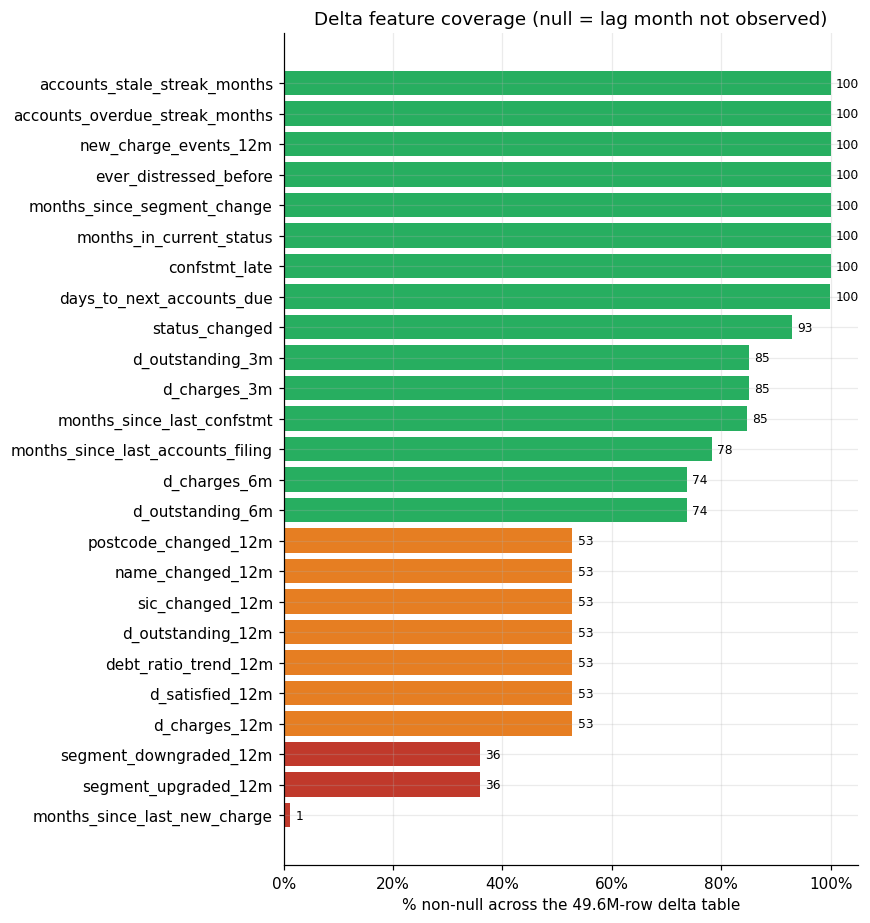

In [5]:
feats = [
    "d_charges_3m", "d_charges_6m", "d_charges_12m",
    "d_outstanding_3m", "d_outstanding_6m", "d_outstanding_12m",
    "d_satisfied_12m", "debt_ratio_trend_12m",
    "new_charge_events_12m", "months_since_last_new_charge",
    "status_changed", "months_in_current_status", "ever_distressed_before",
    "segment_upgraded_12m", "segment_downgraded_12m", "months_since_segment_change",
    "accounts_overdue_streak_months", "accounts_stale_streak_months",
    "confstmt_late", "days_to_next_accounts_due",
    "months_since_last_accounts_filing", "months_since_last_confstmt",
    "sic_changed_12m", "name_changed_12m", "postcode_changed_12m",
]
sel = ", ".join([f'100.0*count("{f}")/count(*) AS "{f}"' for f in feats])
cov_pct = con.execute(f"SELECT {sel} FROM read_parquet('{DELTA_GLOB}')").fetchdf().T
cov_pct.columns = ["pct_non_null"]
cov_pct = cov_pct.sort_values("pct_non_null")

fig, ax = plt.subplots(figsize=(8, 8.5))
colors = ["#c0392b" if v < 40 else "#e67e22" if v < 70 else "#27ae60" for v in cov_pct.pct_non_null]
ax.barh(cov_pct.index, cov_pct.pct_non_null, color=colors)
ax.set_xlabel("% non-null across the 49.6M-row delta table")
ax.set_title("Delta feature coverage (null = lag month not observed)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for y, v in enumerate(cov_pct.pct_non_null):
    ax.text(v + 1, y, f"{v:.0f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

Reads exactly as the dictionary predicts, and the pattern is about *availability*, not about the signal being weak:

- **The 3/6/12m ladder steps down**: `d_charges_3m` ~85%, `_6m` ~74%, `_12m` ~53%. Each step down is the extra companies that had not yet been on the register that far back, plus the June-2025 hole. A NULL here means "we cannot compute this delta because the company was not observed N months ago", not "no change".
- **`months_since_last_new_charge` is ~1%**, and that is correct: it only exists for a company that has *ever* had a new-charge event. Almost no company borrows, so this is a deliberately sparse recency feature; the ~99% of NULLs are "never borrowed".
- **The three new filing features land where they should.** `accounts_stale_streak_months` sits at **100%** (it is defined for every observed row, zero is a real value). The two "stopped filing" recencies are high but not total: `months_since_last_confstmt` ~85% and `months_since_last_accounts_filing` ~78%, because a company that has *never* filed accounts / a confirmation statement has no made-up date to measure from, so it is a true NULL. That is exactly the population where the static `overdue` / `stale` flags do the work instead.
- **Streaks, event counts and `ever_distressed_before` sit at 100%** because they are defined for every observed row (zero is a real value, not a missing one: a healthy company genuinely has a zero overdue streak and zero new-charge events).

The takeaway for modelling: for the 12m features we will be training on roughly half the rows, so the growth label (which needs a 12m lookback) has the thinnest support. Nothing here is broken; it just tells us where the data is dense enough to trust.

## 3. Distributions of the headline deltas (latest snapshot)

I pull the single latest partition into pandas for the distribution plots so this stays fast. On a register this slow-moving, the story is *sparsity*: almost every company is flat month to month, and the signal lives in the thin tails. That is exactly why we skipped 1-month diffs and went to 3/6/12m windows.

In [6]:
latest = con.execute(f"SELECT max(snapshot_date) FROM read_parquet('{DELTA_GLOB}')").fetchone()[0]
df = con.execute(f"""
    SELECT * FROM read_parquet('{DELTA_GLOB}')
    WHERE snapshot_date = DATE '{latest}'
""").df()
print(f"latest snapshot: {latest}  |  rows: {len(df):,}  |  active: {df.is_active.mean():.1%}")
df[["d_charges_3m", "d_charges_12m", "new_charge_events_12m",
    "accounts_overdue_streak_months", "accounts_stale_streak_months",
    "months_since_last_accounts_filing", "months_in_current_status"]].describe().round(3)

latest snapshot: 2026-07-01  |  rows: 1,531,094  |  active: 92.0%


,d_charges_3m,d_charges_12m,new_charge_events_12m,accounts_overdue_streak_months,accounts_stale_streak_months,months_since_last_accounts_filing,months_in_current_status
count,1475182.0,1317528.0,1531094.000,1531094.000,1531094.000,1193043.0,1531094.000
mean,0.003,0.015,0.011,1.124,3.259,16.177,25.122
std,0.084,0.19,0.121,5.475,7.056,214.907,11.614
min,-1.0,-1.0,0.000,0.000,0.000,-95669.0,0.000
25%,0.0,0.0,0.000,0.000,0.000,12.0,15.000
50%,0.0,0.0,0.000,0.000,0.000,16.0,33.000
75%,0.0,0.0,0.000,0.000,2.000,19.0,33.000
max,30.0,55.0,11.000,34.000,34.000,631.0,33.000


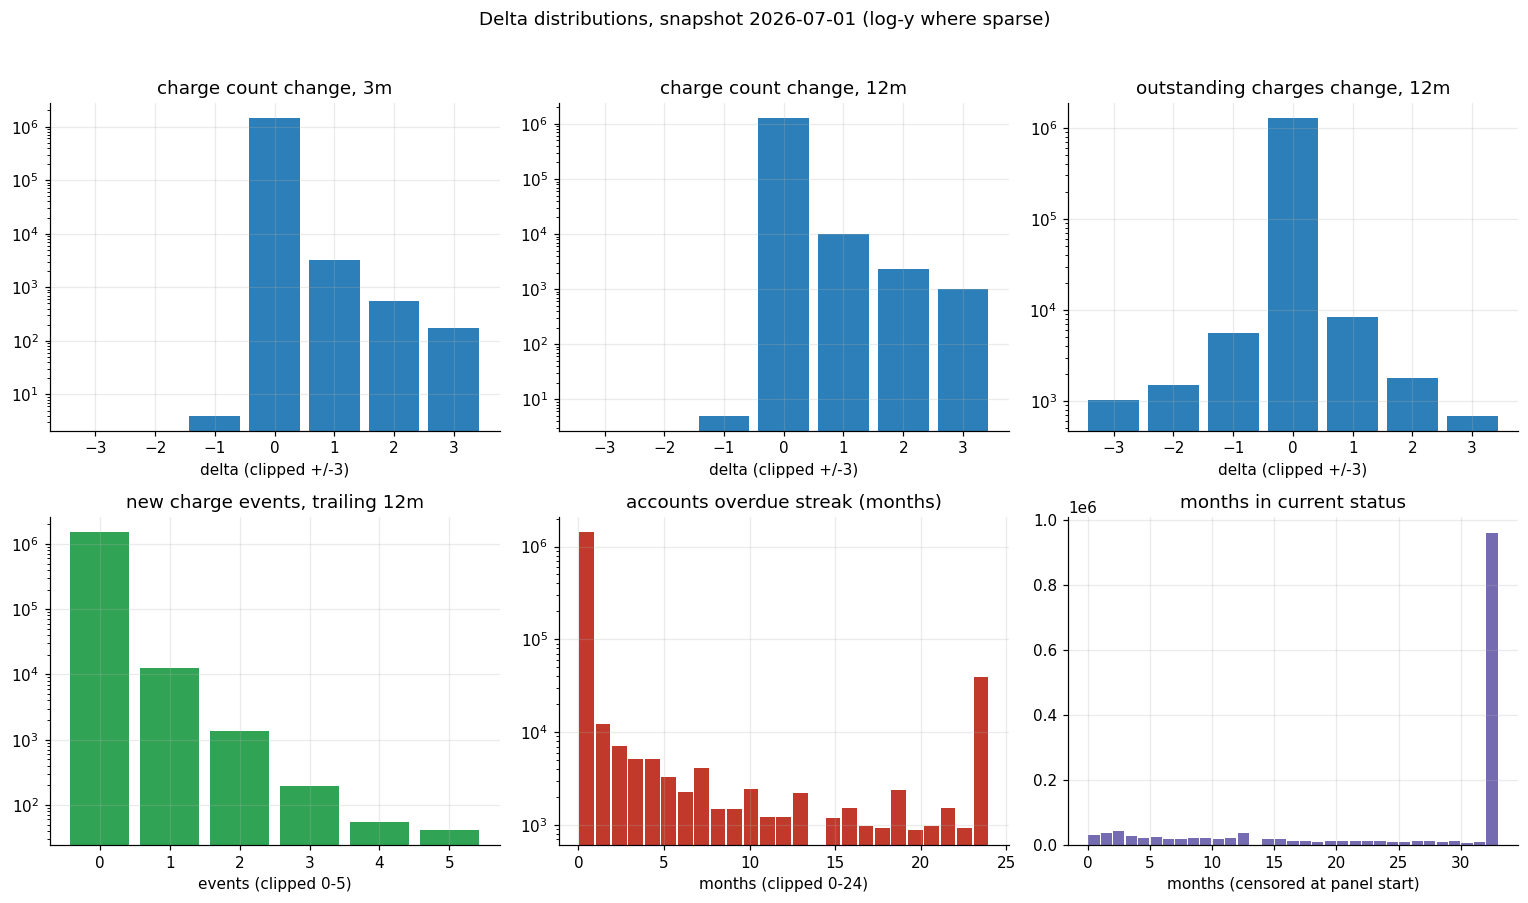

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# charge delta: clip to a readable window, keep zero visible
for ax, col, title in [(axes[0, 0], "d_charges_3m", "charge count change, 3m"),
                        (axes[0, 1], "d_charges_12m", "charge count change, 12m"),
                        (axes[0, 2], "d_outstanding_12m", "outstanding charges change, 12m")]:
    v = df[col].dropna().clip(-3, 3)
    ax.hist(v, bins=np.arange(-3.5, 4.5, 1), color="#2c7fb8", rwidth=0.85)
    ax.set_yscale("log"); ax.set_title(title); ax.set_xlabel("delta (clipped +/-3)")

# new-charge events over trailing 12m
v = df["new_charge_events_12m"].clip(0, 5)
axes[1, 0].hist(v, bins=np.arange(-0.5, 6.5, 1), color="#31a354", rwidth=0.85)
axes[1, 0].set_yscale("log"); axes[1, 0].set_title("new charge events, trailing 12m"); axes[1, 0].set_xlabel("events (clipped 0-5)")

# overdue streak
axes[1, 1].hist(df["accounts_overdue_streak_months"].clip(0, 24), bins=25, color="#c0392b", rwidth=0.9)
axes[1, 1].set_yscale("log"); axes[1, 1].set_title("accounts overdue streak (months)"); axes[1, 1].set_xlabel("months (clipped 0-24)")

# months in current status
axes[1, 2].hist(df["months_in_current_status"].clip(0, 33), bins=33, color="#756bb1", rwidth=0.9)
axes[1, 2].set_title("months in current status"); axes[1, 2].set_xlabel("months (censored at panel start)")

fig.suptitle(f"Delta distributions, snapshot {latest} (log-y where sparse)", y=1.02)
plt.tight_layout(); plt.show()

Now that we know what each feature *means*, the shapes make sense (note the log-y axis on the sparse ones):

- **`d_charges_3m` / `d_charges_12m` (top-left, top-middle)**: a giant spike at 0 with a thin bar at +1. Reading it through the dictionary: almost every company took on *no* new secured borrowing in the window, and the handful at +1 are the ones that took a new charge. That +1 tail is the entire lending signal; it is rare by nature, which is why a single-month diff would be ~99% zeros and we widened to 3/6/12m.
- **`d_outstanding_12m` (top-right)**: same zero-heavy shape, roughly symmetric small tails. A +1 is a company whose live debt grew over the year; a -1 is one that repaid a charge. Both are rare, both are interesting.
- **`new_charge_events_12m` (bottom-left)**: nearly everyone at 0, a few at 1, almost nobody above. So repeated borrowing inside a single year is genuinely rare, which is why a company showing 2+ events is a strong "active borrower" flag rather than noise.
- **`accounts_overdue_streak_months` (bottom-middle)**: a huge zero bar (accounts filed on time) trailing into a long thin tail out to ~24+ months. The dictionary said "short blip is noise, long streak is distress", and the histogram shows exactly that separation, a dense healthy mass and a sparse deep-delinquency tail.
- **`months_in_current_status` (bottom-right)**: piles up at 33 (the panel length). Read through the dictionary: most companies simply stayed `Active` for the entire window, so their run-length is the whole panel. It is censored at the panel start, so 33 means "at least 33", not "exactly 33".

### And the three new filing features

Same latest snapshot, plotted on their own because they read differently from the charge deltas: these are not "change since N months ago" but "how long since the last filing / how long stale". A healthy company sits in a low, tight band (it files roughly annually); the distress signal is the long right tail of companies whose filing clock has run away.

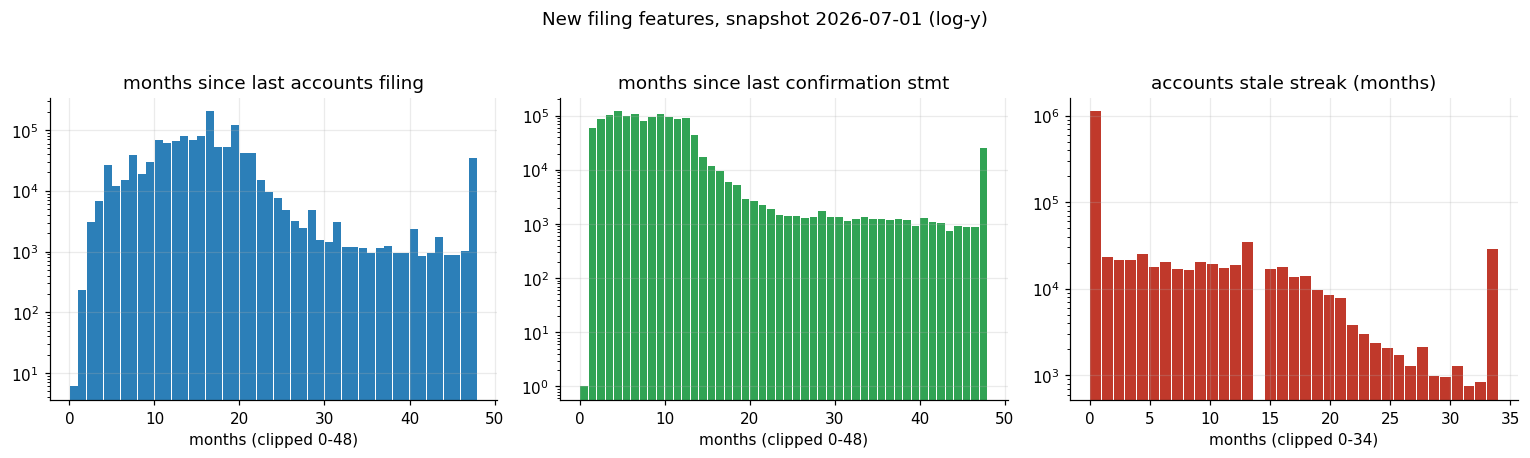

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# months since last accounts filing: healthy sawtooth peaks ~12-21m, distress tail runs out
axes[0].hist(df["months_since_last_accounts_filing"].dropna().clip(0, 48), bins=48, color="#2c7fb8", rwidth=0.9)
axes[0].set_yscale("log"); axes[0].set_title("months since last accounts filing")
axes[0].set_xlabel("months (clipped 0-48)")

# months since last confirmation statement: tighter annual cycle
axes[1].hist(df["months_since_last_confstmt"].dropna().clip(0, 48), bins=48, color="#31a354", rwidth=0.9)
axes[1].set_yscale("log"); axes[1].set_title("months since last confirmation stmt")
axes[1].set_xlabel("months (clipped 0-48)")

# stale streak: huge zero bar (accounts fresh) trailing into a deep-stale tail
axes[2].hist(df["accounts_stale_streak_months"].clip(0, 34), bins=35, color="#c0392b", rwidth=0.9)
axes[2].set_yscale("log"); axes[2].set_title("accounts stale streak (months)")
axes[2].set_xlabel("months (clipped 0-34)")

fig.suptitle(f"New filing features, snapshot {latest} (log-y)", y=1.03)
plt.tight_layout(); plt.show()

Reading them through the dictionary:

- **`months since last accounts filing` (left)**: the dense mass sits in the low-to-mid teens of months, which is the normal cadence (accounts are annual, and can be filed up to ~9 months after the period end, so even a punctual filer sits around 12-21 months). The long thin tail past ~30 months is the interesting part: companies whose accounts clock has run away because they stopped filing. That tail is the leading distress signal we did not have before.
- **`months since last confirmation stmt` (middle)**: a tighter version of the same shape, because the confirmation statement is a simpler annual obligation, so the healthy band is narrower and the runaway tail is cleaner.
- **`accounts stale streak` (right)**: mirrors the overdue streak from the previous figure, a huge zero bar (accounts on file are current) trailing into a long tail out toward the full panel length. A company stuck at 30-plus months of stale accounts has effectively gone quiet.

And the split by status backs this up: on the latest snapshot, non-Active companies average ~38 months since their last accounts filing versus ~14 for Active ones, and a stale streak of ~15 months versus ~2. So the runaway tail really is the failing companies, which is exactly the separation the distress target in Step 5 needs.

## 4. Does the signal separate the classes it should?

The whole reason to build deltas is that they should look different for companies heading into trouble versus healthy ones. This is the sanity check before any model: split the latest snapshot by `is_active` and compare the risk-flavoured features. If these do not separate, the labels in Step 5 have nothing to learn from.

In [9]:
sep = con.execute(f"""
    SELECT is_active,
           count(*)                                    AS n,
           avg(accounts_overdue::INT)                  AS pct_overdue,
           avg(accounts_overdue_streak_months)         AS avg_overdue_streak,
           avg(ever_distressed_before::INT)            AS pct_ever_distressed,
           avg(new_charge_events_12m)                  AS avg_new_charges_12m,
           avg(confstmt_late::INT)                     AS pct_confstmt_late
    FROM read_parquet('{DELTA_GLOB}')
    WHERE snapshot_date = DATE '{latest}'
    GROUP BY is_active ORDER BY is_active
""").df()
sep

,is_active,n,pct_overdue,avg_overdue_streak,pct_ever_distressed,avg_new_charges_12m,pct_confstmt_late
0,False,121810,0.610910,13.133429,0.930663,0.001519,0.794291
1,True,1409284,0.017957,0.085524,0.037965,0.011443,0.044839


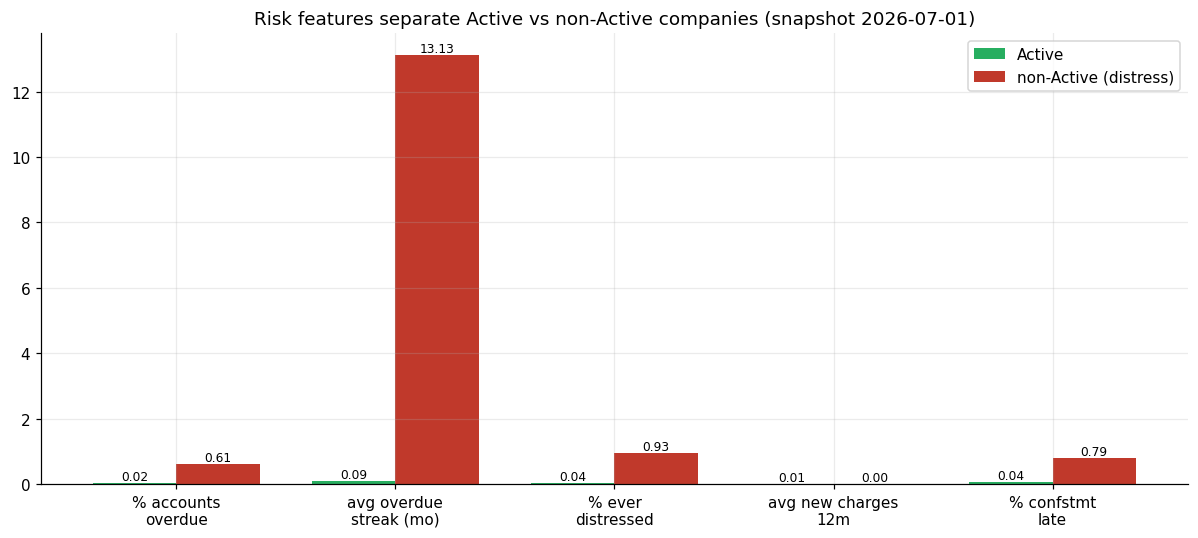

In [10]:
metrics = ["pct_overdue", "avg_overdue_streak", "pct_ever_distressed",
           "avg_new_charges_12m", "pct_confstmt_late"]
labels = ["% accounts\noverdue", "avg overdue\nstreak (mo)", "% ever\ndistressed",
          "avg new charges\n12m", "% confstmt\nlate"]
active = sep.loc[sep.is_active, metrics].values.flatten()
failed = sep.loc[~sep.is_active, metrics].values.flatten()

x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, active, w, label="Active", color="#27ae60")
b2 = ax.bar(x + w/2, failed, w, label="non-Active (distress)", color="#c0392b")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title(f"Risk features separate Active vs non-Active companies (snapshot {latest})")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

Clean separation, and every bar moves in the direction the dictionary says it should:

- **`% accounts overdue`, `avg overdue streak`, `% confstmt late`**: all far higher for non-Active companies. These are the "filing behaviour" features, our earliest liveness tells, and they light up hard for the distressed group: non-Active companies are overdue ~61% of the time with an average streak of ~13 months, versus ~2% and near-zero for Active ones. This is the distress signal doing exactly its job.
- **`% ever distressed`**: non-Active companies almost all carry a prior scare on record, Active ones rarely do. Consistent with "distress tends to recur".
- **`avg new charges 12m` inverts, and that is the important one.** Non-Active companies have *fewer* new charges than Active ones. Reading it through the dictionary: a new charge means a lender extended fresh secured credit, and lenders do not lend into a failing business. So the lending signal (new charges up) and the distress signal (filing behaviour up) genuinely point in opposite directions.

That opposition is the whole reason the three targets in Step 5 are separable: a healthy borrower and a failing company do not look alike on these features, so a model has real structure to learn rather than one blurred "activity" axis.

## 5. Sharing the dataset

Right now the dataset is a **folder of 33 parquet files** (`data/processed/panel_deltas/`), which is efficient but assumes the other person has DuckDB or pandas and knows to point at the folder. There are two ways to hand it over:

- **The whole folder as-is.** Zip `data/processed/panel_deltas/` and send it. Stays partitioned and fast, but they must read it the way we do (`read_parquet('.../panel_deltas/**/*.parquet')`).
- **One portable file** (what the cell below produces). Collapse the 33 partitions into a single `.parquet` they can open anywhere in one line.

For a hand-off I recommend the **single file**. I use `.parquet` rather than `.csv` on purpose: it stays compressed (about 1 GB instead of several GB of text), preserves the column types and the NULLs exactly (a CSV turns every NULL into an ambiguous empty string, which would wreck the "missing vs zero" distinction the deltas depend on), and opens in one line from pandas, DuckDB, R, or Excel Power Query. If the recipient truly needs CSV, swap the `COPY` line to `(FORMAT CSV, HEADER)` and expect a much larger file.

A note on what the file is *not*: it is the feature matrix, not a live database. There is no server and nothing to log into; "the database" is just this file (or folder) of parquet. Whoever receives it queries it locally with DuckDB or pandas exactly as we do here.

In [11]:
# Collapse the 33 partitions into ONE portable parquet file to hand to someone.
# This writes a brand-new file; it does not touch the panel or delta folders.
SHARE_PATH = REPO_ROOT / "data/processed/panel_deltas_full.parquet"

if SHARE_PATH.exists():
    print(f"already exists, not rewriting: {SHARE_PATH.name}")
else:
    con.execute(f"""
        COPY (SELECT * FROM read_parquet('{DELTA_GLOB}'))
        TO '{SHARE_PATH.as_posix()}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print(f"wrote {SHARE_PATH.name}")

n = con.execute(f"SELECT count(*) FROM read_parquet('{SHARE_PATH.as_posix()}')").fetchone()[0]
size_gb = SHARE_PATH.stat().st_size / 1e9
print(f"one shareable file: {n:,} rows, {size_gb:.2f} GB")
print("the recipient opens the whole dataset in a single line:")
print("  import pandas as pd; df = pd.read_parquet('panel_deltas_full.parquet')")

wrote panel_deltas_full.parquet
one shareable file: 49,556,152 rows, 1.18 GB
the recipient opens the whole dataset in a single line:
  import pandas as pd; df = pd.read_parquet('panel_deltas_full.parquet')


## Takeaways

- **The shape**: the "big matrix" is `data/processed/panel_deltas/`, a *long* table of ~49.6M rows, **one row per company per month** (not a column per company), stored as 33 partitioned parquet files. See the orientation section up top for the CH-download-to-deltas walkthrough and the CHUBB worked example.
- **25 delta features cover every time-varying source signal**: charges (lending), outstanding/satisfied (leverage), status decay (distress), size tier (growth), filing lateness *and filing cadence*, and identity drift. The section-2 dictionary says what each measures and how to read it.
- **The two biggest gaps are now closed** (section 1b): `months_since_last_accounts_filing` / `months_since_last_confstmt` catch a company that *stops* filing (the earliest distress tell), and `accounts_stale_streak_months` streaks staleness the same way we streak overdue. Remaining, non-blocking: secondary SIC changes and the trivial `PartSatisfied` delta.
- **The deltas are sane**: coverage steps down cleanly with horizon, the new filing features sit where they should (stale streak 100%, filing recency ~78-85%), distributions are correctly zero-heavy, and the risk features separate Active from non-Active as they should.
- **To share it**: the section-5 cell writes one portable `panel_deltas_full.parquet` anyone can open with a single `pd.read_parquet(...)`.

Next up is Step 4 (Contracts Finder as-of join) and Step 5 (the three self-labelled targets).